In [1]:
%matplotlib widget

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, FuncNorm
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
from tqdm.notebook import tqdm

from rlquantopt.utils.analysis_utils import get_pulse_data, get_pulse_spectrum, get_metrics_data

In [2]:
# Directory and pattern for CSV files
par_dir = "/home/leander/code/rlquantopt/rlquantopt/rl_agents"
exp_type = "ZCQPEE_pl-1000_T-50ns_delta_mode-TRPO"
# exp_type = "ZCQPEE_pl-500_T-300ns_delta_mode-TRPO"
exp_date = "05-12-24_201634"
# exp_date = "11-10-24_180134"
log_x = True

save_dir = os.path.abspath(os.path.join(par_dir, f'../rl_analysis/training_metrics_evolution/{exp_type}_{exp_date}'))
print(save_dir)
os.makedirs(save_dir, exist_ok=True)

/home/leander/code/rlquantopt/rlquantopt/rl_analysis/training_metrics_evolution/ZCQPEE_pl-1000_T-50ns_delta_mode-TRPO_05-12-24_201634


In [3]:
# /home/leander/code/rlquantopt/rlquantopt/rl_agents/ZCQPEE_pl-1000_T-50ns_delta_mode-TRPO/05-12-24_201634

# exp_name = os.path.join(exp_date, "results/clip_to_fid_0.9900")
# exp_name = exp_date
save_suffix = '_no_term'

# exp_path = os.path.join(par_dir, exp_type, exp_date, 'results/no_term')
exp_path = f'{par_dir}/{exp_type}/{exp_date}/results/no_term'

# vlines = {'Best agent': {'v': 12566528, 'c': 'g', 'ls': '--'},
          # 'Breakthrough': {'v': 200000, 'c': 'r', 'ls': '--'},
vlines = {
          }
# min_rl_step = int(7e6)set_xscale
min_rl_step = 0
# max_rl_step = int(4e5)
max_rl_step = np.inf
cmap = 'magma'

# file_pattern = f"rl_model_*_steps_ZCQPEE_pl-500_T-300ns_delta_mode_ep0{save_suffix}.csv"

# Store step numbers and spectra
step_numbers = []
spectra = []
concurrences = []
unitarities = []
rewards = []


# Collecting all relevant CSV files and their spectra
for root, _, files in os.walk(exp_path):
    for file in tqdm(files):
        if file.endswith('metrics.csv'):
            continue
        elif file.startswith("rl_model_") and file.endswith(f"{save_suffix}.csv"):
            step_number = int(file.split("_")[2])  # Extracting step number from filename
            if step_number < min_rl_step or step_number > max_rl_step:
                continue

            pulse_file = os.path.join(root, file)
            metrics_file = os.path.join(root, f'{os.path.splitext(file)[0]}_metrics.csv')
            if not os.path.exists(metrics_file):
                continue

            tlist_fine, amps = get_pulse_data(pulse_file)
            tlist_coarse, concurs, unitars, rews = get_metrics_data(metrics_file)

            flist, fabsamps = get_pulse_spectrum(tlist_fine, amps)
            step_numbers.append(step_number)
            spectra.append(fabsamps)
            concurrences.append(concurs)
            unitarities.append(unitars)
            rewards.append(rews)

# Sort by step number
sorted_indices = np.argsort(step_numbers)
step_numbers = np.array(step_numbers)[sorted_indices]
spectra = np.array(spectra)[sorted_indices]
concurrences = np.array(concurrences)[sorted_indices]
# concurrences = 1 - concurrences
unitarities = np.array(unitarities)[sorted_indices]
# unitarities = 1 - unitarities
rewards = np.array(rewards)[sorted_indices]

  0%|          | 0/221 [00:00<?, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

# Spectral evolution

/tmp/ipykernel_17800/2362079081.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.85])  # Make space at the top


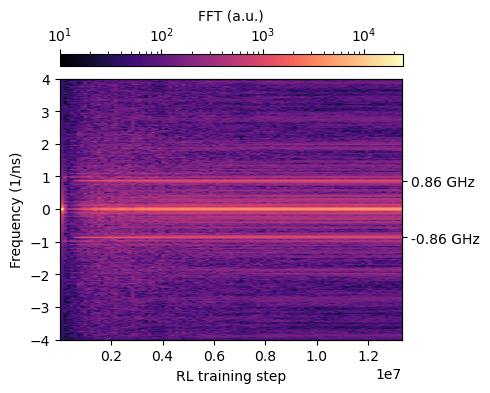

In [4]:
'''
Plotting the spectral evolution
'''
# fig.suptitle("Spectral evolution during RL training")
# ax.set_title(f'Experiment: {exp_type} - {exp_date}')
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(
    spectra.T, aspect='auto', extent=[min(step_numbers), max(step_numbers),flist[0], flist[-1]],
    origin='lower', norm=LogNorm(vmin=1e1), cmap=cmap
)
pos = ax.get_position()
cbar_left = pos.x0+0.005
cbar_width = pos.x1 - pos.x0 - 0.09
cbar_bottom = 0.83
cbar_height = 0.03
cax = fig.add_axes([cbar_left, cbar_bottom, cbar_width, cbar_height])
cbar = fig.colorbar(im, cax=cax, orientation='horizontal')

cbar.ax.xaxis.set_label_position('top')
cbar.ax.xaxis.tick_top()
cbar.set_label('FFT (a.u.)')

# cbar_ax = fig.add_axes([0.85, 0.15, 0.03, 0.7])  # [left, bottom, width, height]
# cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.15)
# cbar.set_label('FFT (a.u)')

# if log_x: ax.set_xscale('log')
ax.set_xlabel("RL training step")
ax.set_ylabel("Frequency (1/ns)")

freq_lim_ghz = 4
ax.set_ylim((-freq_lim_ghz, freq_lim_ghz))

# Add ticks at ±0.86 GHz on the right spine
model_freq = 0.86
ax_markers = ax.twinx()
ax_markers.set_ylim(ax.get_ylim())
ax_markers.yaxis.set_ticks([])
ax_markers.yaxis.set_tick_params(right=True, labelright=True)
ax_markers.set_yticks([-model_freq, model_freq])
ax_markers.set_yticklabels([f'{-model_freq:.2f} GHz', f'{model_freq:.2f} GHz'])

# fig.tight_layout()
fig.tight_layout(rect=[0, 0, 1, 0.85])  # Make space at the top
plt.show()

In [ ]:
fig.savefig(os.path.join(save_dir, 'spectra_evolution.pdf'))

# Concurrence error evolution

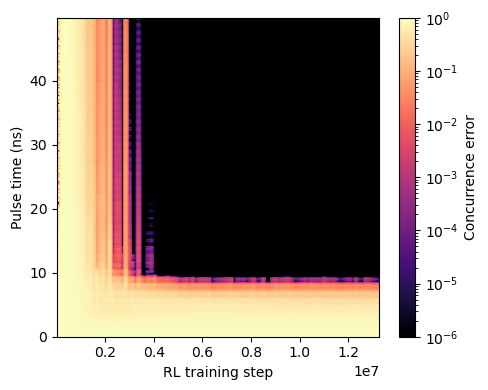

In [5]:
'''
Plotting the concurrence evolution
'''
fig, ax = plt.subplots(figsize=(5, 4))
# fig.suptitle("Concurrence evolution during RL training")
# ax.set_title(f'Experiment: {exp_type} - {exp_date}')
concur_min = 1e-6
concur_error  = 1 - concurrences.T
concur_error_clipped = np.clip(concur_error, concur_min, 1)
im = ax.imshow(
    concur_error_clipped, aspect='auto', extent=[min(step_numbers), max(step_numbers), 0, tlist_coarse[-1]],
    origin='lower', norm=LogNorm(vmin=concur_min, vmax=1), cmap=cmap
    # origin='lower', cmap=cmap
)
# for k, v in vlines.items():
#     if k == 'Best agent' and v['v'] > max_rl_step:
#         continue
#     ax.axvline(v['v'], color=v['c'], lw=1.4, linestyle=v['ls'], label=k)

# Compute QSL

# Finish up plot
fig.colorbar(im, label='Concurrence error')
# if log_x:
    # ax.set_xscale('log')
ax.set_xlabel("RL training step")
ax.set_ylabel("Pulse time (ns)")
# ax.legend(loc='best')

fig.tight_layout()
plt.show()

In [75]:
fig.savefig(os.path.join(save_dir, 'concurrence_evolution.pdf'))

# Unitarity error evolution

In [6]:
from scipy.ndimage import minimum_filter
import matplotlib.ticker as ticker

unitar_error Min=1.25e-04 Max=4.91e-01


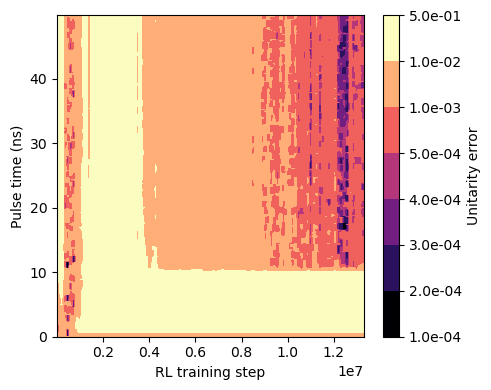

In [8]:
'''
Plotting the unitarities evolution
'''
fig, ax = plt.subplots(figsize=(5, 4))
# unitar_error = median_filter(1 - unitarities.T, size=3)
unitar_error = 1 - unitarities.T
unitar_error = minimum_filter(unitar_error, size=(7,1))

print(f'unitar_error Min={unitar_error.min():.2e} Max={unitar_error.max():.2e}')

# Define breakpoints for colormap distribution
breakpoints = [1e-4, 2e-4, 3e-4, 4e-4, 5e-4, 1e-3, 1e-2, 5e-1]

# Create a custom normalization that redistributes colors
# norm_values = np.linspace(0, 1, len(breakpoints)*10)  # Mapping each breakpoint to a normalized value
norm = mcolors.BoundaryNorm(breakpoints, ncolors=256, clip=False)
# norm = mcolors.LogNorm(vmin=breakpoints[0], vmax=breakpoints[-1])  # Log scale for smooth transitions


# Plot heatmap
im = ax.imshow(
    unitar_error, aspect='auto', extent=[min(step_numbers), max(step_numbers), 0, tlist_coarse[-1]],
    origin='lower', norm=norm, cmap=cmap#, alpha=0.6
)

# Add contour at 1e-4 and 1e-3 using the same colormap
contour_levels = [concur_error.min()]
cs = ax.contour(
    step_numbers, tlist_coarse, unitar_error, levels=contour_levels, colors='black', linewidths=1.5
)
ax.clabel(cs, inline=False, fontsize=10, fmt='%.1e')

cbar = fig.colorbar(im, label='Unitarity error')

# Set tick locations for reference
cbar.set_ticks(breakpoints)
cbar.set_ticklabels([f"{x:.1e}" for x in breakpoints])

# # Manually add lines to the colorbar to indicate contour positions
# for level in contour_levels:
#     cbar.ax.axhline(y=level, color='red', linestyle=':', linewidth=1.5)  # Highlight contours in red



# if log_x: ax.set_xscale('log')
# ax.legend(loc='best')
ax.set_xlabel("RL training step")
ax.set_ylabel("Pulse time (ns)")
# ax.set_xlim(0.8e7, max(step_numbers))
fig.tight_layout()
plt.show()

In [72]:
save_dir

'/home/leander/code/rlquantopt/rlquantopt/rl_analysis/training_metrics_evolution/ZCQPEE_pl-1000_T-50ns_delta_mode-TRPO_05-12-24_201634'

In [9]:
fig.savefig(os.path.join(save_dir, f"unitarity_evolution.pdf"))

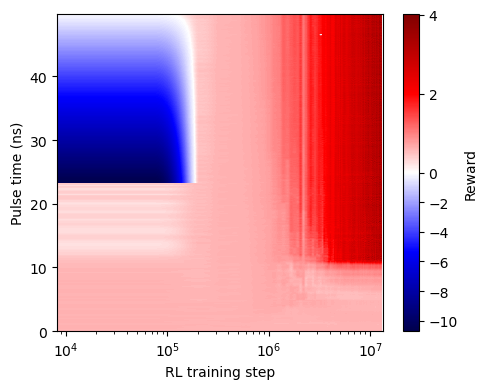

In [10]:
'''
Plotting the rewards evolution
'''
fig, ax = plt.subplots(figsize=(5, 4))
rew_cmap = plt.get_cmap('seismic')
norm = mcolors.TwoSlopeNorm(vmin=np.min(rewards), vcenter=0, vmax=np.max(rewards))

im = ax.imshow(
    rewards.T, aspect='auto', extent=[min(step_numbers), max(step_numbers), 0, tlist_coarse[-1]],
    origin='lower', cmap=rew_cmap, norm=norm
)
# fig.suptitle("Reward evolution during RL training")
# ax.set_title(f'Experiment: {exp_type} - {exp_date}')
# ax.set_xscale('log')
for k, v in vlines.items():
    if k == 'Best agent' and v['v'] > max_rl_step:
        continue
    ax.axvline(v['v'], color=v['c'], lw=1.4, linestyle=v['ls'], label=k)
# ax.legend(loc='best')
fig.colorbar(im, label='Reward')
if log_x: ax.set_xscale('log')
ax.set_xlabel("RL training step")
ax.set_ylabel("Pulse time (ns)")
fig.tight_layout()
plt.show()

In [11]:
fig.savefig(os.path.join(save_dir, f"reward_evolution.pdf"))
# plt.show()